## **Health insurance Prediction** 

## **Problem Statement**


Health insurance charges vary significantly among individuals based on factors such as age, BMI, smoking habits, number of children, gender, and region. Manually estimating insurance costs can be difficult and may not provide accurate results. Therefore, there is a need for a data-driven system that can analyze these factors and predict the expected health insurance charges. The proposed system uses data analysis and machine learning techniques to identify the relationship between customer characteristics and insurance costs, helping to provide accurate and reliable insurance charge predictions.



## **Objective**


To analyze health insurance data based on factors such as age, gender, BMI, number of children, smoking status, and region.

To identify the important factors that influence health insurance charges.

To preprocess and clean the insurance dataset for accurate analysis.

To perform exploratory data analysis and visualize patterns in insurance charges.

To develop a machine learning model for predicting individual health insurance charges.

To evaluate the performance and accuracy of the prediction model using suitable evaluation metrics.

To provide an efficient and data-driven approach for estimating health insurance costs.


## **Data Description**

The dataset used in this project contains **1,338 records and 7 attributes** related to health insurance customers. It is used to analyze the factors that influence health insurance charges and to predict the insurance cost using Machine Learning.

 Attribute         Description                                                                                  
   
 **age**    -      Age of the individual in years.  

 **sex**    -    Gender of the individual (male or female). 

 **bmi**    -     Body Mass Index of the individual, which indicates body weight relative to height.

 **children**  -  Number of children or dependents covered by the insurance.

 **smoker**  -    Indicates whether the individual is a smoker or non-smoker.

 **region**  -    Residential region of the individual. 

 **charges** -    Medical insurance cost charged to the individual. This is the **target variable** for prediction. 
 

The dataset contains both **numerical and categorical variables**. The `age`, `bmi`, `children`, and `charges` attributes are numerical, while `sex`, `smoker`, and `region` are categorical. The **charges** attribute is used as the output variable for predicting health insurance costs.


In [1]:
!pip install pandas
!pip install numpy


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install seaborn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install matplotlib 


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
!pip install sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

## **Installing and Importing Neccessary Libraries**

The following Python libraries are installed and imported for data analysis, visualization, preprocessing, and building the Machine Learning model:


Pandas – Used for data loading, manipulation, and analysis.

NumPy – Used for numerical calculations and array operations.


Matplotlib – Used for creating graphs and visualizations.

Seaborn – Used for statistical data visualization.

Scikit-learn – Used for data preprocessing, splitting the dataset, building the Linear Regression model, and evaluating model performance.


These libraries provide the necessary tools to preprocess the health insurance dataset, perform exploratory data analysis, train the prediction model, and evaluate its accuracy.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# **Loading the data**

In [7]:
data = pd.read_csv("C:/Users/DHARANISH-PC/Downloads/insurance_prediction (1).csv")

## **Data Overview**

The dataset contains 1,338 records and 7 columns. It provides information about individuals and their health insurance costs. The main purpose of the dataset is to understand how factors such as age, BMI, smoking status, number of children, gender, and region affect health insurance charges.


Number of Records: 1,338

Number of Attributes: 7

Target Variable: charges

Numerical Variables: age, bmi, children, charges

Categorical Variables: sex, smoker, region

Missing Values: No missing values

Duplicate Records: 1 duplicate record was identified.


## **data shape**

Data Shape: The dataset contains 1,338 rows and 7 columns.

In [8]:
data.shape

(1338, 7)

## **data head**

data.head(10) displays the first 10 rows of the dataset.

In [9]:
data.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


## **data tail**

data.tail(10) displays the last 10 rows of the dataset.

In [10]:
data.tail(10)

,age,sex,bmi,children,smoker,region,charges
1328,23,female,24.225,2,no,northeast,22395.74424
1329,52,male,38.600,2,no,southwest,10325.20600
1330,57,female,25.740,2,no,southeast,12629.16560
1331,23,female,33.400,0,no,southwest,10795.93733
1332,52,female,44.700,3,no,southwest,11411.68500
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500
1337,61,female,29.070,0,yes,northwest,29141.36030


## **data info**

data.info() displays the dataset’s structure, column names, data types, and non-null values.

In [11]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


## **data.describe()**

data.describe() displays the statistical summary of numerical columns, such as count, mean, minimum, maximum, and standard deviation.

In [12]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## **data.describe().T**

data.describe().T displays the statistical summary of numerical columns in a transposed format, making each column appear as a row.

In [13]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


## **data.describe(include='object')**

data.describe(include='object') displays the summary of categorical columns, including count, unique values, top value, and its frequency.

In [14]:
data.describe(include='object')

C:\Users\DHARANISH-PC\AppData\Local\Temp\ipykernel_11680\3382516499.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include='object')


,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


## **Duplicate Rows**

duplicate_rows checks for any duplicate rows in the dataset and prints the total count of duplicates found.

In [15]:
duplicate_rows = data[data.duplicated()]
print(f"Number of duplicate rows: {len(duplicate_rows)}")
duplicate_rows

Number of duplicate rows: 1


,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [ ]:
data = data.drop_duplicates()

print(f"Shape after removi Sng duplicates: {data.shape}")

Shape after removi Sng duplicates: (1337, 7)


## **EDA - Exploratory Data Analysis**

## **Univariate Analyis**

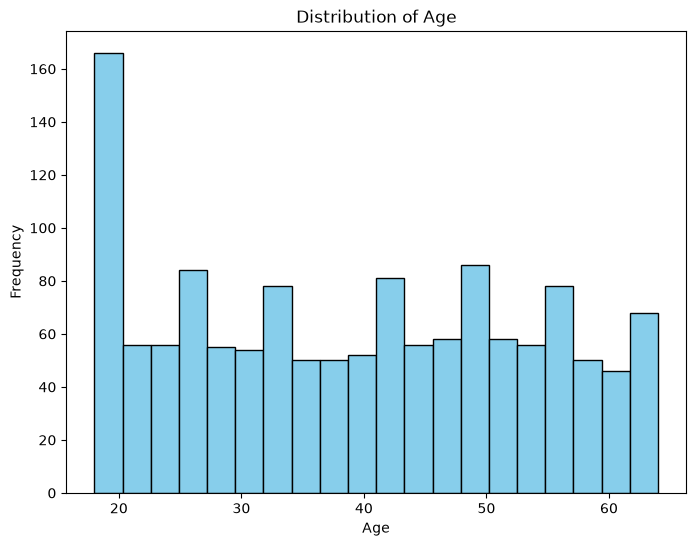

In [16]:
plt.figure(figsize=(8,6))
plt.hist(data['age'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

## **Interpretation of the Distribution of age**

Code Functionality: The script uses matplotlib.pyplot to generate a histogram visualizing the 'age' column from the data dataframe.

Bin Configuration: The data is divided into 20 equal-width bins to show the frequency distribution across different age ranges.

Visual Styling: The histogram uses sky-blue bars with black borders to clearly distinguish each bin and improve readability.

Primary Peak: The first bin (starting near age 18) shows a massive concentration, with a frequency exceeding 160 individuals.

Dataset Characteristic: The prominent initial spike suggests a large cohort of young adults or a minimum age boundary in the dataset.

Remaining Distribution: Across the rest of the age span (roughly 21 to 65), the frequencies are relatively stable and flat, mostly hovering between 45 and 90.

Overall Shape: The distribution is non-normal and heavily weighted toward the younger bracket due to the sharp initial drop-off.

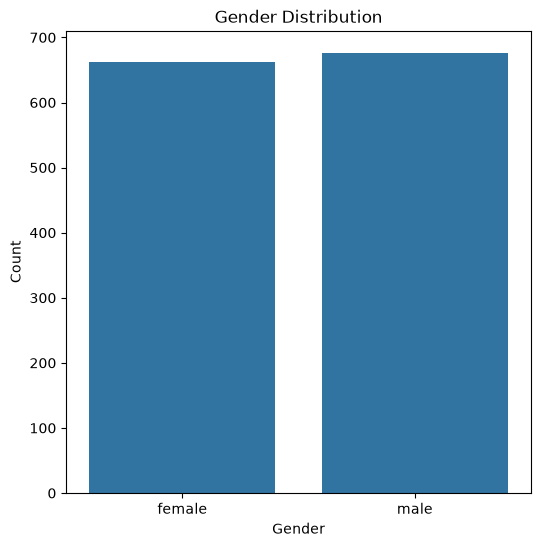

In [17]:
plt.figure(figsize=(6, 6))
sns.countplot(x='sex', data=data)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

## **Interpretation of the Gender Distribution**

This bar chart shows the number of male and female people in the dataset.


X-axis → Gender (female / male)

Y-axis → Number of people (Count)

The number of females is around 660.

The number of males is around 675.

Both genders have almost equal representation.

There are slightly more males than females in the dataset.


Text(0.5, 0, 'Smoker')

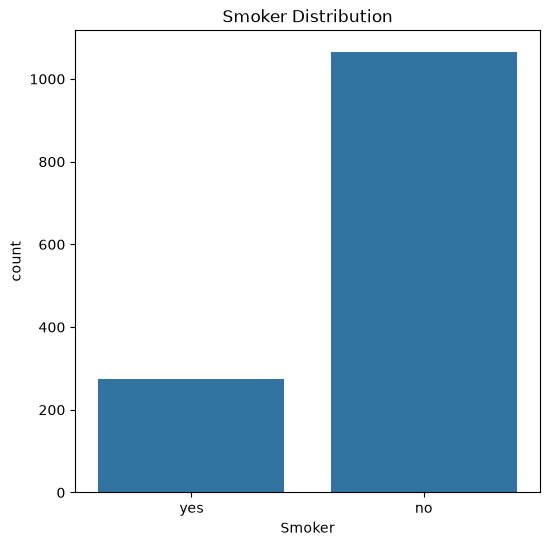

In [18]:
plt.figure(figsize=(6, 6))
sns.countplot(x='smoker', data=data)
plt.title('Smoker Distribution')
plt.xlabel('Smoker')

## **Interpretation of the Smoker Distribution**


This bar chart shows the number of smokers and non-smokers in the dataset.

X-axis → Smoker status (yes / no)

Y-axis → Number of people (count)

The “yes” bar is around 275, meaning fewer people are smokers.

The “no” bar is around 1,060, meaning most people are non-smokers.

Therefore, the dataset contains many more non-smokers than smokers.


## **Bivariate Analysis**

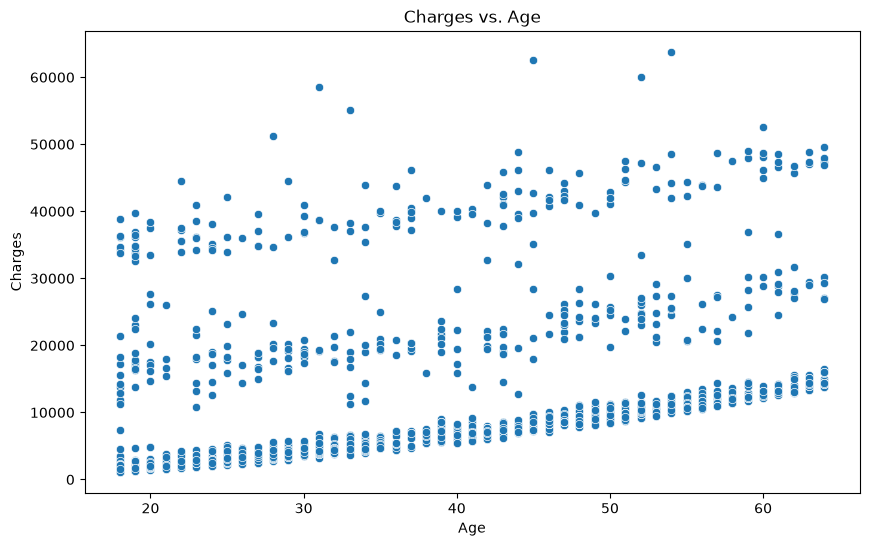

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='charges', data=data)
plt.title('Charges vs. Age')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()

## **Interpretation of Charges vs. Age**

This scatter plot shows the relationship between age and medical charges.

X-axis → Age

Y-axis → Medical Charges

As age increases, medical charges generally increase.

Younger people tend to have lower charges, while older people generally have higher charges.

The points are widely scattered, so age is not the only factor affecting charges.

Some people have very high charges, which can be considered unusual values/outliers.

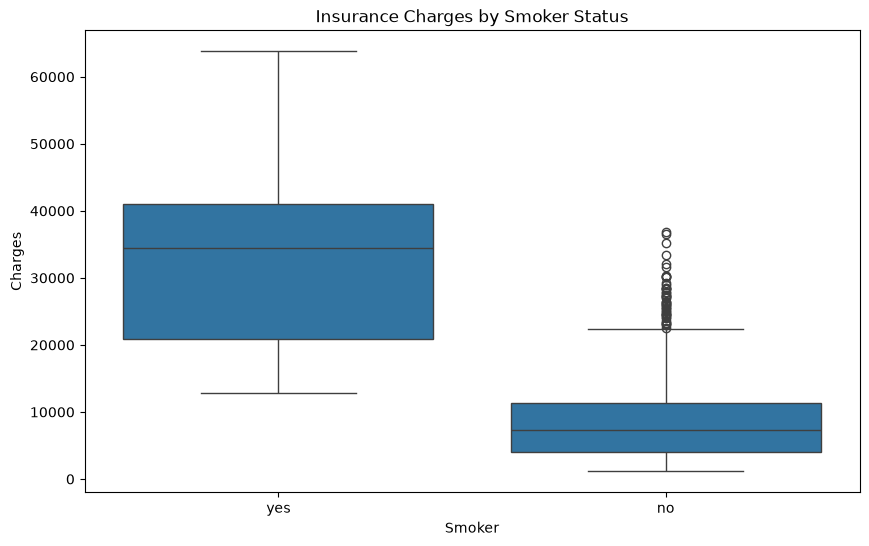

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='smoker', y='charges', data=data)
plt.title('Insurance Charges by Smoker Status')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.show()

## **Interpretation of Insurance Charges by Smoker Status**

This box plot compares insurance charges between smokers and non-smokers.


X-axis → Smoker status (yes / no)

Y-axis → Insurance charges

Smokers (yes) have much higher insurance charges than non-smokers.

The median charge for smokers is around ₹34,000, while for non-smokers it is around ₹7,000.

Smokers also have a wider range of charges.

Non-smokers have several high-value outliers.

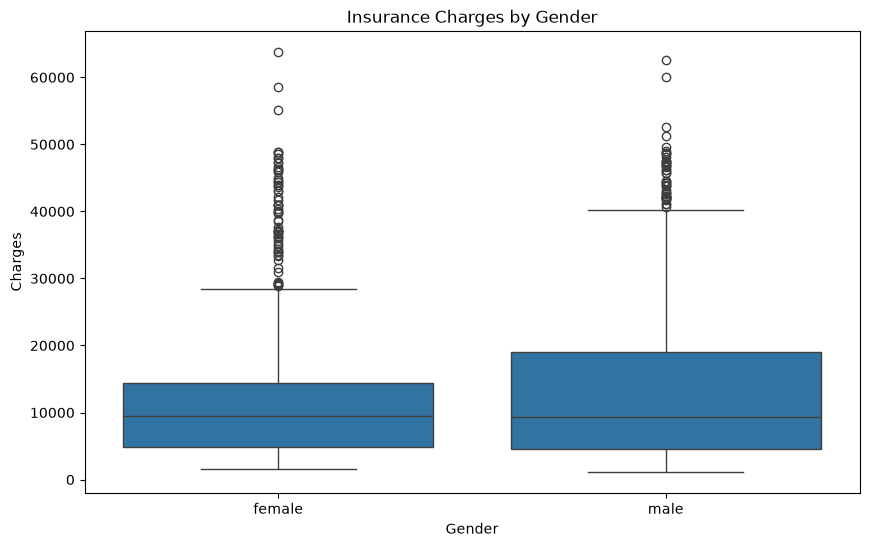

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='sex', y='charges', data=data)
plt.title('Insurance Charges by Gender')
plt.xlabel('Gender')
plt.ylabel('Charges')
plt.show()

## **Interpretation of Insurance Charges by Gender**

This box plot compares insurance charges between females and males.

X-axis → Gender (female / male)

Y-axis → Insurance charges

The median charges for females and males are almost similar, around ₹9,000–₹10,000.

Males have a slightly wider range of insurance charges.

Both genders have several high-value outliers, showing some people have unusually high charges.

Overall, gender does not show a very large difference in insurance charges compared with factors such as smoking.


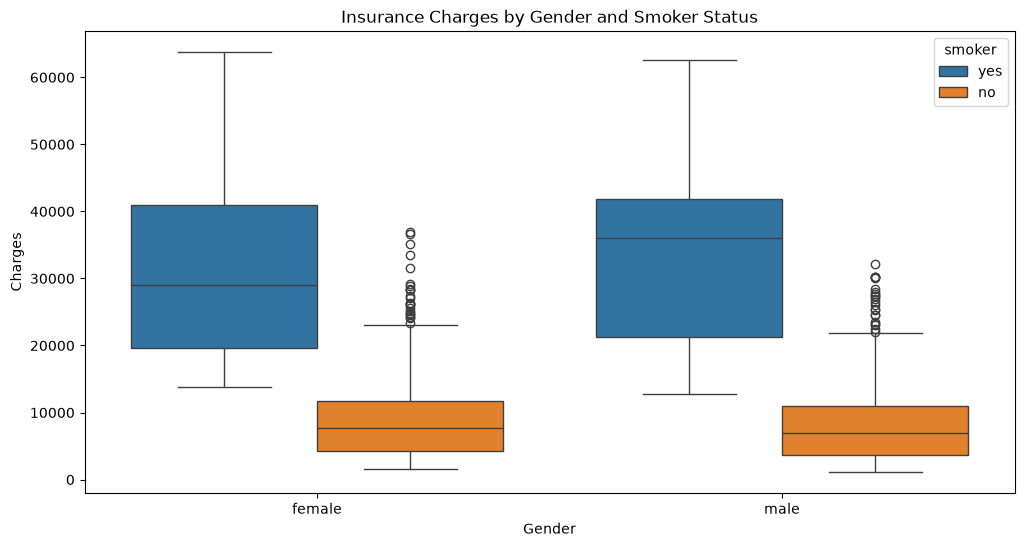

In [22]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='sex', y='charges', hue='smoker', data=data)
plt.title('Insurance Charges by Gender and Smoker Status')
plt.xlabel('Gender')
plt.ylabel('Charges')
plt.show()

## **Interpretation of Insurance Charges by Gender and Smoker Status**

This box plot compares insurance charges based on both gender and smoking status.

X-axis → Gender (female / male)

Y-axis → Insurance charges

Smoker = Yes: Both male and female smokers have much higher insurance charges.

Smoker = No: Both male and female non-smokers have much lower charges.

Among smokers, males have a slightly higher median charge than females.

Among non-smokers, the charges for males and females are fairly similar.

There are some high-value outliers, especially among non-smokers.


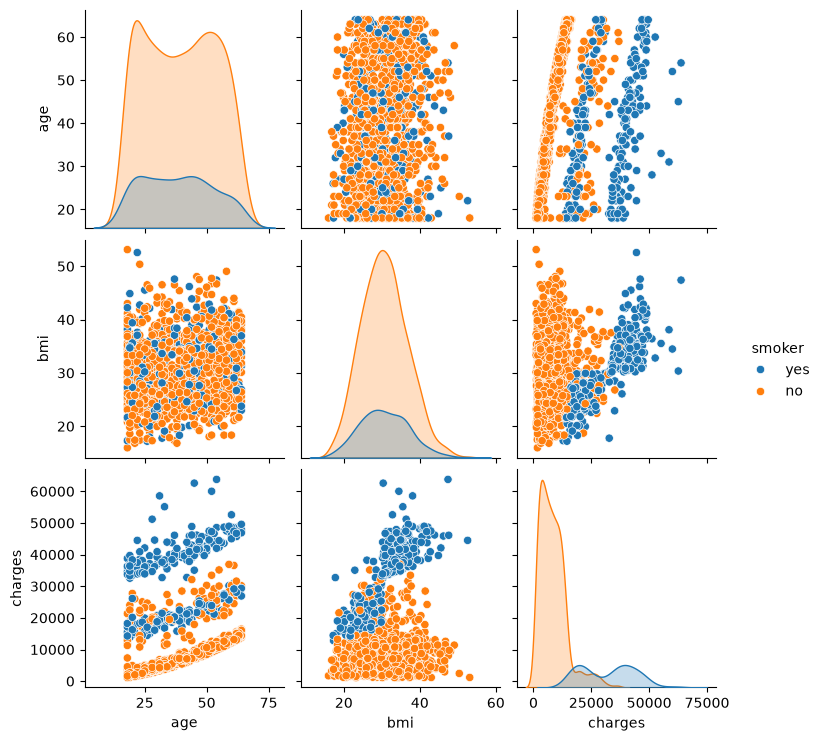

In [23]:
sns.pairplot(data, vars=['age', 'bmi', 'charges'], hue='smoker')
plt.show()

## **Interpretation of the Pair Plot**

This pair plot shows the relationship between age, BMI, and insurance charges, separately for smokers and non-smokers.



Age vs Charges: Insurance charges generally increase as age increases, especially for smokers.

BMI vs Charges: Smokers tend to have higher charges, and there is some positive relationship between BMI and charges.

Age vs BMI: There is no strong relationship between age and BMI; the points are widely scattered.

Charges Distribution: Smokers have much higher insurance charges compared with non-smokers.

The blue points (smokers) are mainly concentrated at higher charge values.

The orange points (non-smokers) are mostly concentrated at lower charge values.


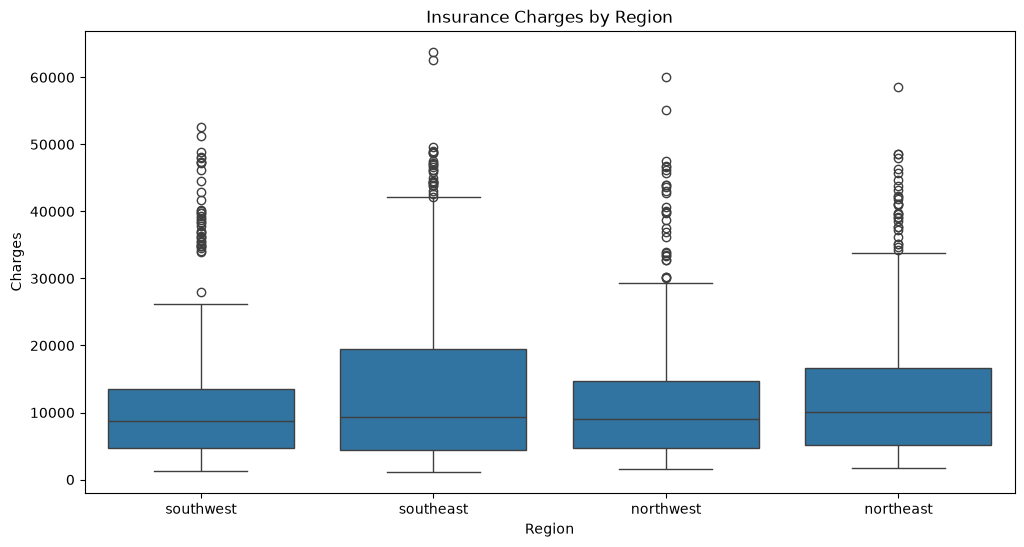

In [24]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='region', y='charges', data=data)
plt.title('Insurance Charges by Region')
plt.xlabel('Region')
plt.ylabel('Charges')
plt.show()

## **Interpretation of Insurance Charges by Region**

This box plot compares insurance charges across four regions.


X-axis → Region

Y-axis → Insurance charges

The Northeast region has a slightly higher median charge compared to the other regions.

Southwest has a relatively lower median charge.

Southeast shows a wider variation in insurance charges.

All regions have some high-value outliers, meaning a few people have unusually high charges.

Overall, the difference in charges between regions is not very large compared with factors like smoking


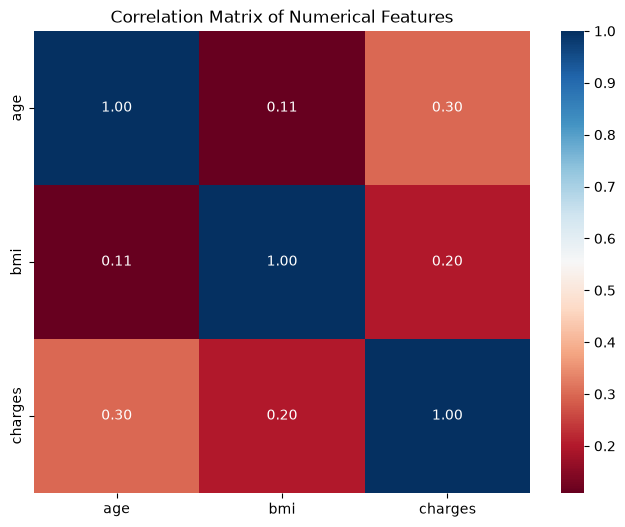

In [25]:
numerical_cols = ['age', 'bmi', 'charges']
correlation_matrix = data[numerical_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()


## **Interpretation of the Correlation Matrix**

This heatmap shows the relationship between the numerical features: age, bmi, and charges.


Age vs Charges = 0.30 → There is a weak positive relationship. As age increases, charges tend to increase slightly.

BMI vs Charges = 0.20 → There is a weak positive relationship. Higher BMI is associated with slightly higher charges.

Age vs BMI = 0.11 → There is very weak positive relationship, meaning age and BMI are almost independent.

The diagonal values are 1.00 because each variable has a perfect correlation with itself.


## **Data Preprocessing**

## **data.columns**

data.columns is used to display all the column names in a dataset.

In [26]:
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

It converts text categories into numerical 0 and 1 values for machine learning.

In [27]:
data = pd.get_dummies(data, columns=['sex', 'smoker', 'region'], drop_first=True, dtype=int)

 data.head() displays the first 5 rows of the dataset.

In [28]:
data.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


In [29]:
x = data.drop('charges', axis=1)
y = data['charges']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

The charges column is considered as the output/target variable (y) that we want the model to predict.

x stores the input variables/features such as age, BMI, smoker, region, etc., which help in predicting the insurance charges.

y contains the actual insurance charge values that the machine learning model will learn to predict.

train_test_split() is used to divide the dataset into two parts: training data and testing data.

test_size=0.3 indicates that 30% of the data is reserved for testing, while the remaining 70% is used for training.

random_state=42 keeps the data splitting consistent, so the same training and testing sets are created every time.

Thus, the dataset is prepared for training the model and checking its prediction performance.


In [30]:
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)  
print("y_test shape:", y_test.shape) 

x_train shape: (936, 8)
x_test shape: (402, 8)
y_train shape: (936,)
y_test shape: (402,)


x_train.shape displays the number of rows and columns in the training input data.

x_test.shape displays the number of rows and columns in the testing input data.

y_train.shape displays the number of values in the training target data.

y_test.shape displays the number of values in the testing target data.

The shape function is used to check the size and dimensions of the datasets.

This helps verify that the data has been split correctly into training and testing sets.

In [31]:
model_eval_results = pd.DataFrame(columns=['Model', 'Train_MSE', 'Train_R2', 'Test_MSE', 'Test_R2'])

pd.DataFrame() creates an empty table to store the model evaluation results.
The columns Model, Train_MSE, Train_R2, Test_MSE, and Test_R2 are created.
Train_MSE and Test_MSE store the Mean Squared Error values for training and testing data.
Train_R2 and Test_R2 store the R² score values for training and testing data.
The Model column stores the name of each machine learning model.
This DataFrame is used to compare the performance of different models.

In [33]:
x_train_m1 = x_train[['age']]
x_test_m1 = x_test[['age']]
model_1 = LinearRegression()
results=model_1.fit(x_train_m1, y_train)

x_train_m1 = x_train[['age']] → Selects the age column from the training data as the input feature.
x_test_m1 = x_test[['age']] → Selects the age column from the testing data.
model_1 = LinearRegression() → Creates a Linear Regression model.
model_1.fit(x_train_m1, y_train) → Trains the model using age as the input and insurance charges as the target.
results stores the trained model results.

In [34]:
print(f"LinearRegression Equation: Charges ={ model_1.intercept_:.2f} + ({ model_1.coef_[0]:.2f} * Age)")

LinearRegression Equation: Charges =3673.84 + (247.60 * Age)


model_1.intercept_ gives the starting value of insurance charges when Age is 0.
model_1.coef_[0] gives the change in insurance charges for every 1-year increase in age.
The f-string formats the values to 2 decimal places.
The code prints the Linear Regression equation in the form:

Charges = Intercept + (Coefficient × Age)

In [35]:
y_train_pred_m1 = model_1.predict(x_train_m1)
y_test_pred_m1 = model_1.predict(x_test_m1)

train_mse_m1 = mean_squared_error(y_train, y_train_pred_m1)
train_r2_m1 = r2_score(y_train, y_train_pred_m1)

test_mse_m1 = mean_squared_error(y_test, y_test_pred_m1)
test_r2_m1 = r2_score(y_test, y_test_pred_m1)

model_eval_results.loc[len(model_eval_results)] = ['Model 1 (Age Only)', train_mse_m1, train_r2_m1, test_mse_m1, test_r2_m1]

model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.342518e+08,0.083408,1.316614e+08,0.102049


model_1.predict(x_train_m1) → Predicts insurance charges for the training data using Age.
model_1.predict(x_test_m1) → Predicts insurance charges for the testing data using Age.
mean_squared_error() → Calculates the Mean Squared Error (MSE) for training and testing predictions.
r2_score() → Calculates the R² score, which shows how well the model explains the variation in insurance charges.
model_eval_results.loc[...] → Adds Model 1 (Age Only) and its Train MSE, Train R², Test MSE, and Test R² to the results table.
model_eval_results → Displays the model evaluation results

## **Model 2**

In [36]:
x_train_m2 = x_train[['age','bmi']]
x_test_m2 = x_test[['age','bmi']]
model_2 = LinearRegression()
results=model_2.fit(x_train_m2, y_train)

x_train_m2 = x_train[['age','bmi']] → Selects Age and BMI as input features from the training data.
x_test_m2 = x_test[['age','bmi']] → Selects Age and BMI from the testing data.
model_2 = LinearRegression() → Creates a Linear Regression model.
model_2.fit(x_train_m2, y_train) → Trains the model using Age and BMI to predict insurance charges.
results stores the trained model.

In [ ]:
print(f'LinearRegression Equation: Charges = {model_2.intercept_:.2f} + ({model_2.coef_[0]:.2f}) * Age) +({model_2.coef_[1]:.2f}* BMI)')

LinearRegression Equation: Charges = -3641.79 + (227.40) * Age) +(254.94* BMI)


model_2.intercept_ → Gives the starting value of insurance charges when Age and BMI are 0.
model_2.coef_[0] → Gives the effect of Age on insurance charges.
model_2.coef_[1] → Gives the effect of BMI on insurance charges.
The code prints the Linear Regression equation using both Age and BMI.
:.2f formats the values to 2 decimal places.

Simple: This code displays the Linear Regression equation used to predict insurance charges based on Age and BMI.

In [ ]:
y_train_pred_m2 = model_2.predict(x_train_m2)
y_test_pred_m2 = model_2.predict(x_test_m2)

train_mse_m2 = mean_squared_error(y_train, y_train_pred_m2)
train_r2_m2 = r2_score(y_train, y_train_pred_m2)

test_mse_m2 = mean_squared_error(y_test, y_test_pred_m2)
test_r2_m2 = r2_score(y_test, y_test_pred_m2)

model_eval_results.loc[len(model_eval_results)] = ['Model 2 (Age and BMI)', train_mse_m2, train_r2_m2, test_mse_m2, test_r2_m2]

model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.246248e+08,0.082229,1.545219e+08,0.096985
1,Model 2 (Age and BMI),1.222942e+08,0.099392,1.471034e+08,0.140338


y_train_pred_m2 → Predicts insurance charges for the training data using Age and BMI.
y_test_pred_m2 → Predicts insurance charges for the testing data using Age and BMI.
mean_squared_error() → Calculates the MSE for training and testing predictions.
r2_score() → Calculates the R² score to measure the model's performance.
model_eval_results.loc[...] → Adds Model 2 (Age and BMI) and its evaluation scores to the results table.
model_eval_results → Displays the updated model comparison table.

## **Model 3**

In [37]:
x_train_m3 = x_train[['age','bmi']]
x_test_m3 = x_test[['age','bmi']]
model_3 = LinearRegression()
results=model_3.fit(x_train_m3, y_train)

x_train_m3 = x_train[['age','bmi']] → Selects Age and BMI as input features from the training data.
x_test_m3 = x_test[['age','bmi']] → Selects Age and BMI from the testing data.
model_3 = LinearRegression() → Creates a Linear Regression model.
model_3.fit(x_train_m3, y_train) → Trains the model using Age and BMI to predict insurance charges.
results stores the trained model.

In [38]:
model_3 = LinearRegression()
model_3.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 261.3 , 348.91, 424.12,...,-486.93,-970.97,-926.32]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['age','bmi','children',...,'region_northwest','region_southeast', 'region_southwest']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.237e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


model_3 = LinearRegression() → Creates a Linear Regression model.
model_3.fit(x_train, y_train) → Trains Model 3 using all the input features in x_train to predict the insurance charges in y_train.
This model uses the complete training dataset features, rather than selecting only Age and BMI.

In [39]:
y_train_pred_m3 = model_3.predict(x_train)
y_test_pred_m3 = model_3.predict(x_test)

train_mse_m3 = mean_squared_error(y_train, y_train_pred_m3)
train_r2_m3 = r2_score(y_train, y_train_pred_m3)

test_mse_m3 = mean_squared_error(y_test, y_test_pred_m3)
test_r2_m3 = r2_score(y_test, y_test_pred_m3)

model_eval_results.loc[len(model_eval_results)] = ['Model 3 (All Features)', train_mse_m3, train_r2_m3, test_mse_m3, test_r2_m3]

model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.342518e+08,0.083408,1.316614e+08,0.102049
1,Model 3 (All Features),3.773055e+07,0.742398,3.378051e+07,0.769612


y_train_pred_m3 → Predicts insurance charges for the training data using all features.
y_test_pred_m3 → Predicts insurance charges for the testing data using all features.
mean_squared_error() → Calculates the MSE for both training and testing predictions.
r2_score() → Calculates the R² score to measure the model's performance.
model_eval_results.loc[...] → Adds Model 3 (All Features) and its evaluation scores to the results table.
model_eval_results → Displays the updated comparison of all models.